# Chapter 030 — Number Patterns

> **Prerequisites:** ch029 (Factorization), ch028 (Prime Numbers), ch022 (Natural Numbers)
> 
> **You will learn:**
> - Recognize and generate Fibonacci, triangular, and figurate numbers
> - Derive closed-form expressions from observed patterns
> - Understand OEIS and how patterns are catalogued
> - Analyze patterns computationally before attempting proofs
> 
> **Environment:** Python 3.x, numpy, matplotlib

---


## 1. Concept

Number patterns are regularities in sequences of integers. They appear in:
- Nature (Fibonacci spirals in sunflowers, pinecones, nautilus shells)
- Algorithms (Fibonacci heaps, recurrence relations)
- Combinatorics (Pascal's triangle, Catalan numbers)
- Geometry (triangular numbers, perfect squares, pentagonal numbers)

The computational approach: observe → conjecture → verify → prove. In this chapter we focus on the first two steps, using code to identify and test patterns before committing to formal proof.

**Common misconception:** "If I've verified a pattern for 1000 cases, it must be true." Ramanujan conjectured a formula that held for millions of cases before Littlewood found a counterexample. Verification is evidence, not proof.

## 2. Intuition & Mental Models

**Fibonacci: nature's recursion.** Start with 1, 1. Each term is the sum of the previous two: 1, 1, 2, 3, 5, 8, 13, 21, 34, 55... The ratio of consecutive terms converges to φ = (1+√5)/2 (the golden ratio from ch025).

**Triangular numbers as staircase arrangements:** 1, 3, 6, 10, 15... — the nth triangular number is 1+2+3+...+n = n(n+1)/2. Stack 1 block, then 2, then 3... you get a staircase.

**Pascal's triangle contains everything:** Row n of Pascal's triangle gives binomial coefficients C(n,k). Hidden in it: triangular numbers (diagonal), Fibonacci numbers (diagonal sums), powers of 2 (row sums), Sierpinski gasket (mod 2 coloring).

*(Recall from ch022: Pascal's triangle was built from natural numbers; now we see it encodes algebraic structure.)*

## 3. Visualization

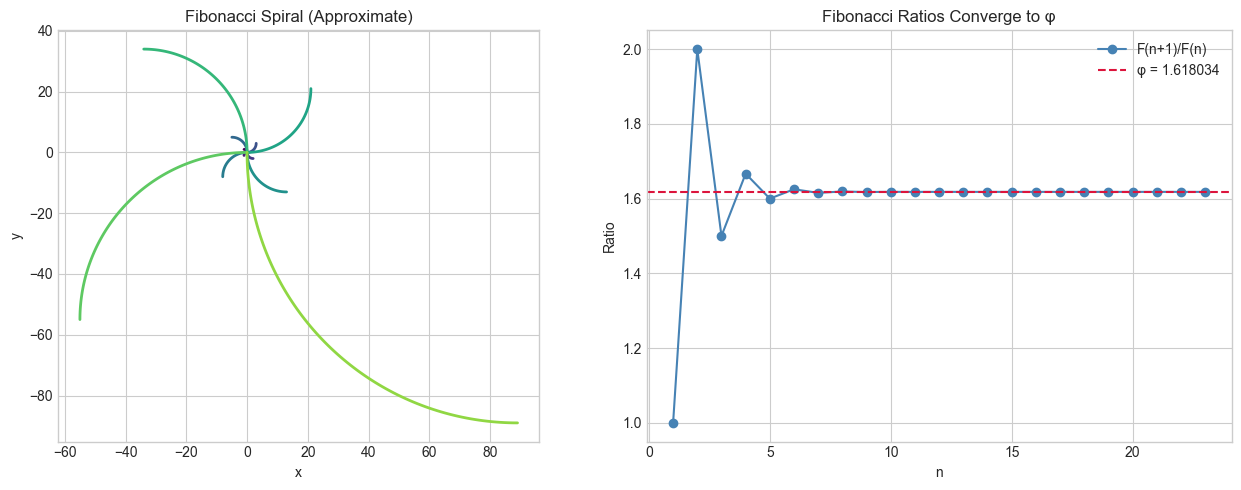

First 15 Fibonacci: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
Golden ratio φ = 1.6180339887


In [1]:
# --- Visualization: Fibonacci spiral, Pascal, and sequence families ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def fibonacci(n):
    a, b = 0, 1
    result = []
    for _ in range(n):
        result.append(a)
        a, b = b, a + b
    return result

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Fibonacci spiral approximation
ax = axes[0]
fibs = fibonacci(12)
x, y = 0, 0
angle = 0
for i, f in enumerate(fibs[1:]):
    t = np.linspace(angle * np.pi/2, (angle + 1) * np.pi/2, 100)
    r = f
    cx = x + r * np.cos(angle * np.pi/2 + np.pi)
    cy = y + r * np.sin(angle * np.pi/2 + np.pi)
    ax.plot(cx + r * np.cos(t), cy + r * np.sin(t), color=plt.cm.viridis(i/12), linewidth=2)
    angle = (angle + 1) % 4
ax.set_aspect('equal')
ax.set_title('Fibonacci Spiral (Approximate)')
ax.set_xlabel('x')
ax.set_ylabel('y')

# Plot 2: Convergence of Fibonacci ratios to golden ratio
ax = axes[1]
fibs_arr = fibonacci(25)
ratios = [fibs_arr[i+1]/fibs_arr[i] for i in range(1, len(fibs_arr)-1)]
phi = (1 + np.sqrt(5)) / 2
ax.plot(range(1, len(ratios)+1), ratios, 'o-', label='F(n+1)/F(n)', color='steelblue')
ax.axhline(phi, color='crimson', linestyle='--', label=f'φ = {phi:.6f}')
ax.set_xlabel('n')
ax.set_ylabel('Ratio')
ax.set_title('Fibonacci Ratios Converge to φ')
ax.legend()

plt.tight_layout()
plt.show()

print(f"First 15 Fibonacci: {fibonacci(15)}")
print(f"Golden ratio φ = {phi:.10f}")

## 4. Mathematical Formulation

See implementation below for numeric verification.

## 5. Python Implementation

In [2]:
# --- Implementation: Sequence generators and pattern detection ---
import numpy as np

def fibonacci_gen():
    """Infinite Fibonacci generator."""
    a, b = 0, 1
    while True:
        yield a
        a, b = b, a + b

def figurate(s, n):
    """nth s-gonal number. s=3: triangular, s=4: square, s=5: pentagonal."""
    return n * ((s - 2) * n - (s - 4)) // 2

def catalan(n):
    """nth Catalan number: C(n) = C(2n,n)/(n+1). Counts many combinatorial structures."""
    from math import comb
    return comb(2 * n, n) // (n + 1)

def differences(seq):
    """Compute successive differences of a sequence until constant."""
    diffs = [list(seq)]
    while len(set(diffs[-1])) > 1:
        d = diffs[-1]
        diffs.append([d[i+1] - d[i] for i in range(len(d)-1)])
        if len(diffs[-1]) < 2:
            break
    return diffs

# Triangular numbers: differences should become constant
tri = [figurate(3, n) for n in range(1, 10)]
print("Triangular numbers:", tri)
diffs = differences(tri)
print("Differences:")
for i, d in enumerate(diffs):
    print(f"  Level {i}: {d}")

# Catalan numbers
cats = [catalan(n) for n in range(10)]
print(f"\nCatalan numbers: {cats}")

# Binet's formula for Fibonacci
phi = (1 + np.sqrt(5)) / 2
psi = (1 - np.sqrt(5)) / 2
def fib_binet(n):
    """Closed-form Fibonacci via Binet's formula."""
    return round((phi**n - psi**n) / np.sqrt(5))

print("\nBinet formula vs recursive (first 15):")
gen = fibonacci_gen()
for i in range(15):
    actual = next(gen)
    binet = fib_binet(i)
    print(f"  F({i}) = {actual}  (Binet: {binet})  {'✓' if actual == binet else '✗'}")

Triangular numbers: [1, 3, 6, 10, 15, 21, 28, 36, 45]
Differences:
  Level 0: [1, 3, 6, 10, 15, 21, 28, 36, 45]
  Level 1: [2, 3, 4, 5, 6, 7, 8, 9]
  Level 2: [1, 1, 1, 1, 1, 1, 1]

Catalan numbers: [1, 1, 2, 5, 14, 42, 132, 429, 1430, 4862]

Binet formula vs recursive (first 15):
  F(0) = 0  (Binet: 0)  ✓
  F(1) = 1  (Binet: 1)  ✓
  F(2) = 1  (Binet: 1)  ✓
  F(3) = 2  (Binet: 2)  ✓
  F(4) = 3  (Binet: 3)  ✓
  F(5) = 5  (Binet: 5)  ✓
  F(6) = 8  (Binet: 8)  ✓
  F(7) = 13  (Binet: 13)  ✓
  F(8) = 21  (Binet: 21)  ✓
  F(9) = 34  (Binet: 34)  ✓
  F(10) = 55  (Binet: 55)  ✓
  F(11) = 89  (Binet: 89)  ✓
  F(12) = 144  (Binet: 144)  ✓
  F(13) = 233  (Binet: 233)  ✓
  F(14) = 377  (Binet: 377)  ✓


## 6. Experiments

In [3]:
# --- Experiment: Method of differences to find polynomial formulas ---
# Hypothesis: if kth differences of a sequence are constant, it's a degree-k polynomial
# Try changing: the sequence

import numpy as np

def find_polynomial_degree(seq):
    """Find the degree of polynomial generating a sequence via differences."""
    diffs = list(seq)
    degree = 0
    while len(set(diffs)) > 1 and len(diffs) > 1:
        diffs = [diffs[i+1] - diffs[i] for i in range(len(diffs)-1)]
        degree += 1
        if len(diffs) < 2:
            break
    return degree, diffs[0] if diffs else None

# Test sequences  <-- try modifying these
test_sequences = {
    'Triangular':  [n*(n+1)//2 for n in range(1, 12)],
    'Squares':     [n**2 for n in range(1, 12)],
    'Cubes':       [n**3 for n in range(1, 12)],
    'n^4':         [n**4 for n in range(1, 12)],
    'Fibonacci':   [1,1,2,3,5,8,13,21,34,55,89],
}

for name, seq in test_sequences.items():
    deg, const = find_polynomial_degree(seq)
    print(f"{name:15s}: degree = {deg}, constant diff = {const}")

Triangular     : degree = 2, constant diff = 1
Squares        : degree = 2, constant diff = 2
Cubes          : degree = 3, constant diff = 6
n^4            : degree = 4, constant diff = 24
Fibonacci      : degree = 10, constant diff = 34


## 7. Exercises

**Easy 1.** Implement Binet's formula for Fibonacci numbers. For what value of $n$ does float precision cause a wrong answer? *(Hint: try n=75, 76, 77)*

**Easy 2.** Verify that every Fibonacci number divides a later Fibonacci number: $F_m | F_{mk}$ for all $k$. Test for $m=3,5,7$ and $k=1,2,3$.

**Medium 1.** The Collatz sequence from ch022 is defined by $n \to n/2$ (even) or $n \to 3n+1$ (odd). Find the longest Collatz sequence for $n \leq 10000$ and plot stopping times vs $n$.

**Medium 2.** Implement a function that recognizes whether a number is triangular, square, pentagonal, or hexagonal. Apply it to all numbers in [1, 1000].

**Hard.** The Lucas numbers satisfy the same recurrence as Fibonacci but start 2, 1. Prove computationally that $L_n = F_{n-1} + F_{n+1}$ and $F_{2n} = F_n \cdot L_n$. Then find a Binet-like closed form for $L_n$.

## 8. Mini Project

In [ ]:
# --- Mini Project: OEIS Sequence Explorer ---
# Problem: Identify unknown sequences and match them to known patterns.
# Task: Given a list of numbers, detect: arithmetic/geometric/polynomial/Fibonacci-like patterns.

import numpy as np

def analyze_sequence(seq):
    """
    Analyze a sequence and output:
    - Type: arithmetic, geometric, polynomial degree k, Fibonacci-like, or unknown
    - Formula if found
    """
    seq = list(seq)
    n = len(seq)

    # Check arithmetic (1st differences constant)
    d1 = [seq[i+1]-seq[i] for i in range(n-1)]
    if len(set(d1)) == 1:
        return f"Arithmetic: a(n) = {seq[0]} + {d1[0]}*(n-1)"

    # Check geometric (ratios constant)
    ratios = [seq[i+1]/seq[i] for i in range(n-1) if seq[i] != 0]
    if ratios and len(set(round(r, 8) for r in ratios)) == 1:
        return f"Geometric: a(n) = {seq[0]} * {ratios[0]:.4f}^(n-1)"

    # Check polynomial via differences
    diffs = list(seq)
    degree = 0
    while len(set(round(x, 6) for x in diffs)) > 1 and len(diffs) > 1 and degree < 6:
        diffs = [diffs[i+1]-diffs[i] for i in range(len(diffs)-1)]
        degree += 1
    if len(diffs) > 0 and len(set(round(x,4) for x in diffs)) == 1:
        return f"Polynomial degree {degree}"

    # Check Fibonacci-like (a(n) = a(n-1) + a(n-2))
    fib_like = all(abs(seq[i] - seq[i-1] - seq[i-2]) < 1e-6 for i in range(2, n))
    if fib_like:
        return f"Fibonacci-like: a(n) = a(n-1) + a(n-2), starts ({seq[0]}, {seq[1]})"

    return "Unknown pattern"

test_cases = [
    [2, 5, 8, 11, 14, 17],        # arithmetic
    [3, 6, 12, 24, 48, 96],       # geometric
    [1, 4, 9, 16, 25, 36],        # squares
    [1, 8, 27, 64, 125],          # cubes
    [1, 1, 2, 3, 5, 8, 13],      # Fibonacci
    [2, 1, 3, 4, 7, 11, 18],      # Lucas
    [1, 3, 6, 10, 15, 21],        # triangular
]

for seq in test_cases:
    result = analyze_sequence(seq)
    print(f"{str(seq)[:35]:>37}: {result}")

## 9. Chapter Summary & Connections

- Number sequences encode mathematical structure; the method of differences reveals polynomial degree.
- Fibonacci numbers arise from the simplest recurrence and converge to the golden ratio.
- Closed-form expressions (like Binet's formula) convert O(n) recursion to O(1) evaluation.
- Patterns must be proved, not just verified — even a billion confirming cases don't constitute a proof.

**Forward connections:**
- Fibonacci numbers reappear in ch045 — Computational Logarithms (in the analysis of algorithms using the golden ratio).
- Pascal's triangle and binomial coefficients appear in ch241 — Probability and in ch242 — Sample Spaces.
- The method of differences is a discrete analog of differentiation, connecting to ch201 — Calculus: Why It Matters.

**Backward connection:**
- The triangular numbers from ch022 are figurate numbers of a specific type; now we see their systematic structure.

**Going deeper:** The Online Encyclopedia of Integer Sequences (OEIS, oeis.org) contains over 360,000 catalogued sequences with formulas, references, and code. It is an invaluable tool for recognizing patterns in computational experiments.